In [ ]:
#Tahap 1 Pengunduhan data curah hujan harian Kabupaten Kudus Tahun 2016-2025

import ee
import geemap
import pandas as pd
from google.colab import files

project_id = 'cogent-treat-504315-g3' #Inisialisasi GEE dengan project_id yang akan digunakan

try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

print("Autentikasi GEE Berhasil!")

#Panggil batas administrasi Kabupaten Kudus dari Dataset FAO GAUL
kudus_roi = ee.FeatureCollection("FAO/GAUL/2015/level2") \
              .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

#Panggil data CHIRPS daily (2016-01-01 s/d 2025-12-31)
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
           .filterBounds(kudus_roi) \
           .filterDate('2016-01-01', '2025-12-31')

#Fungsi ekstraksi rata-rata hujan harian di Kudus
def extract_daily_precip(image):
    date = image.date().format('YYYY-MM-dd')
    mean_precip = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=kudus_roi,
        scale=5566,  #Resolusi spasial CHIRPS (~5.5 km)
        maxPixels=1e9
    ).get('precipitation')

    return ee.Feature(None, {
        'date': date,
        'precipitation_mm': mean_precip
    })

print("⏳ Sedang mengekstrak data CHIRPS 2016-2025... (Mohon tunggu sebentar)")

#Proses ekstraksi
daily_data = chirps.map(extract_daily_precip)

#Konversi Data GEE ke List Python menggunakan Pandas DataFrame
nested_list = daily_data.reduceColumns(
    ee.Reducer.toList().repeat(2),
    ['date', 'precipitation_mm']
).get('list').getInfo()

df = pd.DataFrame({
    'Tanggal': nested_list[0],
    'Curah_Hujan_mm': nested_list[1]
})

#Memastikan urutan tanggal rapi
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

#Menyimpan dan mengunduh file CSV
filename = 'CHIRPS_Kudus_2016_2025.csv'
df.to_csv(filename, index=False)
print(f"\n🎉 Berhasil! Data {len(df)} hari telah diekstrak.")

#Mengunduh otomatis file ke komputer
files.download(filename)

Autentikasi GEE Berhasil!
⏳ Sedang mengekstrak data CHIRPS 2016-2025... (Mohon tunggu sebentar)

🎉 Berhasil! Data 3652 hari telah diekstrak.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import ee
import geemap
import pandas as pd
from google.colab import files

project_id = 'cogent-treat-504315-g3'

try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

print("Autentikasi GEE Berhasil!")

# -------------------------------------------------------------------------
# PERBAIKAN: Menggunakan Koordinat Bounding Box dari Shapefile Asli Kudus
# Format ee.Geometry.BBox(west/minX, south/minY, east/maxX, north/maxY)
# -------------------------------------------------------------------------
min_x, min_y = 110.75877882231744, -6.979782415740719
max_x, max_y = 110.97725839508003, -6.615995997760439

kudus_roi = ee.Geometry.BBox(min_x, min_y, max_x, max_y)

# Panggil data CHIRPS daily (2016-01-01 s/d 2025-12-31)
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
           .filterBounds(kudus_roi) \
           .filterDate('2016-01-01', '2026-01-01')

# Fungsi ekstraksi rata-rata hujan harian di Kudus
def extract_daily_precip(image):
    date = image.date().format('YYYY-MM-dd')
    mean_precip = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=kudus_roi,
        scale=5566,  # Resolusi spasial CHIRPS (~5.5 km)
        maxPixels=1e9
    ).get('precipitation')

    return ee.Feature(None, {
        'date': date,
        'precipitation_mm': mean_precip
    })

print("⏳ Sedang mengekstrak data CHIRPS 2016-2025 berbasis Bounding Box Shapefile... (Mohon tunggu sebentar)")

# Proses ekstraksi
daily_data = chirps.map(extract_daily_precip)

# Konversi Data GEE ke List Python menggunakan Pandas DataFrame
nested_list = daily_data.reduceColumns(
    ee.Reducer.toList().repeat(2),
    ['date', 'precipitation_mm']
).get('list').getInfo()

df = pd.DataFrame({
    'Tanggal': nested_list[0],
    'Curah_Hujan_mm': nested_list[1]
})

# Memastikan urutan tanggal rapi
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

# 1. Bulatkan curah hujan menjadi 2 angka di belakang koma (misal: 13.19)
df['Curah_Hujan_mm'] = df['Curah_Hujan_mm'].round(2)

# 2. Menyimpan CSV dengan pemisah titik koma (;) dan desimal koma (,) untuk Excel Indonesia
filename = 'CHIRPS_Kudus_2016_2025.csv'
df.to_csv(filename, index=False, sep=';', decimal=',')
print(f"\n🎉 Berhasil! Data {len(df)} hari telah diekstrak dan diformat untuk Excel Indonesia.")

# 3. Mengunduh otomatis file ke komputer
files.download(filename)

Autentikasi GEE Berhasil!
⏳ Sedang mengekstrak data CHIRPS 2016-2025 berbasis Bounding Box Shapefile... (Mohon tunggu sebentar)

🎉 Berhasil! Data 3653 hari telah diekstrak dan diformat untuk Excel Indonesia.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Autentikasi dan Inisialisasi Akses Google Earth Engine

import ee
import geemap

#Jika error 'Project not registered' artinya project 'project_id' belum terdaftar di platform Google Earth Engine
#Solusinya buka: https://console.cloud.google.com/earth-engine/configuration?project=project_id, lalu daftarkan project tersebut

try:
    #Autentikasi
    ee.Authenticate()

    #Inisialisasi project
    project_id = 'cogent-treat-504315-g3'
    ee.Initialize(project=project_id)
    print(f"Berhasil! Project {project_id} siap digunakan.")
except Exception as e:
    print(f"Gagal: {e}")

Berhasil! Project cogent-treat-504315-g3 siap digunakan.


In [ ]:
import ee

def verifikasi_status_gee(project_id):
    print(f"Memeriksa status untuk project: {project_id}...")
    try:
        #Mencoba inisialisasi
        ee.Initialize(project=project_id)
        #Mencoba panggilan API
        ee.data.getAlgorithms()
        print("✅ STATUS: SUKSES. Earth Engine API aktif dan Project sudah terdaftar.")
    except Exception as e:
        error_msg = str(e)
        if "not used in project" in error_msg or "disabled" in error_msg:
            print("❌ STATUS: API BELUM AKTIF.")
            print(f"Silakan klik tautan ini untuk mengaktifkan: https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview?project={project_id}")
        elif "not registered" in error_msg:
            print("❌ STATUS: API AKTIF, TAPI PROJECT BELUM TERDAFTAR.")
            print(f"Silakan daftar di: https://console.cloud.google.com/earth-engine/configuration?project={project_id}")
        else:
            print(f"❌ STATUS: ERROR LAINNYA.\nDetail: {error_msg}")

#Ganti dengan project ID yang akan digunakan
verifikasi_status_gee('cogent-treat-504315-g3')

Memeriksa status untuk project: cogent-treat-504315-g3...
✅ STATUS: SUKSES. Earth Engine API aktif dan Project sudah terdaftar.


In [ ]:
import ee
import geemap
import os

#Menghapus token lama jika ada, untuk memastikan autentikasi bersih
if os.path.exists(os.path.expanduser('~/.config/earthengine/credentials')):
    os.remove(os.path.expanduser('~/.config/earthengine/credentials'))

#Jalankan autentikasi, klik tautan yang muncul, pilih akun Google yang akan digunakan, dan berikan izin akses. Salin kode verifikasi jika diminta
ee.Authenticate()

#Inisialisasi dengan Project ID yang sudah didaftarkan, pastikan sudah daftar di: https://console.cloud.google.com/earth-engine/configuration?project=premium-project_id
project_id = 'cogent-treat-504315-g3'

try:
    ee.Initialize(project=project_id)
    print(f"Berhasil terhubung ke Google Earth Engine dengan project: {project_id}")
except Exception as e:
    print(f"Gagal inisialisasi: {e}")
    print("\nPASTIKAN: Project ID sudah terdaftar di Google Cloud Console dan Earth Engine API sudah diaktifkan.")

Berhasil terhubung ke Google Earth Engine dengan project: cogent-treat-504315-g3


In [ ]:
import ee
import geemap

#Autentikasi & Inisialisasi
ee.Authenticate() #Otorisasi akun Google (Jalankan ini jika diminta login)

#Perbaikan: Tambahkan `project=` dan kurung tanda petik (' ') pada Project ID
ee.Initialize(project='cogent-treat-504315-g3')

#Menentukan wilayah studi : Kabupaten Kudus
#Menggunakan batas administrasi resmi GEE (FAO GAUL Level 2)
kudus = ee.FeatureCollection('FAO/GAUL/2015/level2') \
          .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

#Rentang waktu (Kejadian Banjir Kudus Februari 2024)
# Sebelum banjir (Kondisi Normal)
before_start = '2024-01-01'
before_end   = '2024-01-25'

#Sesudah/Saat kejadian banjir puncak
after_start  = '2024-02-05'
after_end    = '2024-02-20'

#FILTER KOLEKSI SENTINEL-1 SAR (Backscatter VV)
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(kudus) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.eq('instrumentMode', 'IW'))

# Citra sebelum dan sesudah (diambil nilai median)
before_img = s1.filterDate(before_start, before_end).select('VV').median().clip(kudus)
after_img  = s1.filterDate(after_start, after_end).select('VV').median().clip(kudus)

#Hitung perubahan backscatter & eliminasi noise Gunung Muria
#Penurunan nilai dB menandakan adanya genangan air baru
difference = after_img.subtract(before_img)

#Thresholding (Penurunan >3 dB dianggap genangan air baru)
flooded_mask = difference.lt(-3.0)

#Masking lereng curam (> 5 derajat) menggunakan SRTM untuk membuang bayangan radar di Gunung Muria
dem = ee.Image('USGS/SRTMGL1_003').clip(kudus)
slope = ee.Terrain.slope(dem)
flooded_clean = flooded_mask.updateMask(slope.lt(5))

# 5. VISUALISASI INTERAKTIF
Map = geemap.Map()
Map.centerObject(kudus, 11) # Zoom otomatis tepat di Kabupaten Kudus

#Menampilkan Layer
Map.addLayer(before_img, {'min': -25, 'max': 0}, 'Sebelum Banjir (SAR - Jan 2024)')
Map.addLayer(after_img, {'min': -25, 'max': 0}, 'Saat Banjir (SAR - Feb 2024)')
Map.addLayer(flooded_clean.updateMask(flooded_clean), {'palette': ['red']}, 'Area Tergenang Banjir (Kudus)')
Map.addLayer(kudus, {'color': 'black', 'fillColor': '00000000'}, 'Batas Kab. Kudus')

Map

Map(center=[-6.7905981968281655, 110.86913151414201], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
import pandas as pd

#Menghitung luas banjir Kabupaten Kudus km²
flood_area_km2 = flooded_clean.multiply(ee.Image.pixelArea()).divide(1000000)

total_flood = flood_area_km2.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=kudus.geometry(),
    scale=10,
    maxPixels=1e9
)

total_km2 = total_flood.get('VV').getInfo()

#EKSTRAKSI ZONAL & EKSPOR KE EXCEL (MENGGUNAKAN BOUNDING BOX KUDUS)
#Ambil boundary resmi Kudus yang sudah pasti terload
kudus_feature = kudus.first()

#Buat rekapitulasi data Kabupaten Kudus
data_list = [{
    'Kabupaten': 'Kudus',
    'Total_Luas_Banjir_km2': round(total_km2, 2),
    'Keterangan': 'Puncak Banjir Februari 2024 (Sentinel-1 SAR)'
}]

#Buat DataFrame Pandas
df_banjir_clean = pd.DataFrame(data_list)

#Simpan ke file Excel
df_banjir_clean.to_excel("Ringkasan_Banjir_Kudus_km2.xlsx", index=False)

print(f"📊 Total Luas Area Tergenang Banjir di Kab. Kudus: {total_km2:.2f} km²")
print("✅ BERHASIL! File 'Ringkasan_Banjir_Kudus_km2.xlsx' berhasil di-download.")
df_banjir_clean

📊 Total Luas Area Tergenang Banjir di Kab. Kudus: 27.65 km²
✅ BERHASIL! File 'Ringkasan_Banjir_Kudus_km2.xlsx' berhasil di-download.


,Kabupaten,Total_Luas_Banjir_km2,Keterangan
0,Kudus,27.65,Puncak Banjir Februari 2024 (Sentinel-1 SAR)


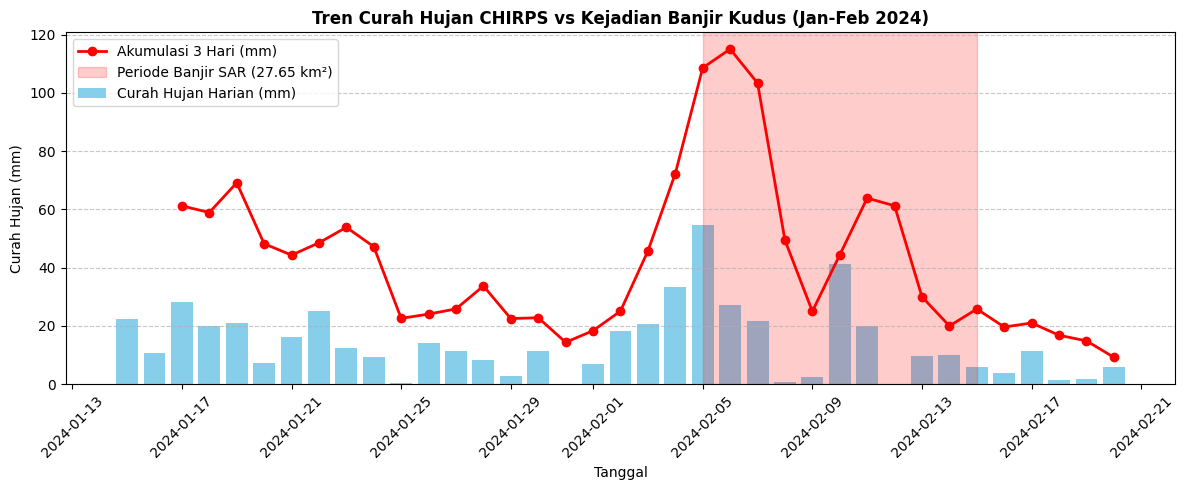

,Tanggal,Curah_Hujan_mm,Akumulasi_3Hari_mm,Akumulasi_5Hari_mm
21,2024-02-05,54.58,108.61,133.72
26,2024-02-10,41.13,44.40,93.21
20,2024-02-04,33.41,72.33,79.14
2,2024-01-17,28.13,61.24,NaN
22,2024-02-06,27.06,115.05,153.97
7,2024-01-22,25.18,48.55,89.58
0,2024-01-15,22.36,NaN,NaN
23,2024-02-07,21.75,103.39,157.42
4,2024-01-19,20.96,69.16,102.27
19,2024-02-03,20.62,45.73,57.31


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. AMBIL DATA CURAH HUJAN CHIRPS (HARIAN)
# Periode pengamatan: 15 Januari - 20 Februari 2024
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
           .filterBounds(kudus) \
           .filterDate('2024-01-15', '2024-02-21')

# Fungsi ekstraksi nilai rata-rata curah hujan (mm/hari) di Kudus
def extract_rainfall(image):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=kudus.geometry(),
        scale=5000, # Resolusi CHIRPS ~5km
        maxPixels=1e9
    )
    date = image.date().format('YYYY-MM-dd')
    return ee.Feature(None, {
        'Tanggal': date,
        'Curah_Hujan_mm': stats.get('precipitation')
    })

# Eksekusi ekstraksi
rain_features = chirps.map(extract_rainfall).getInfo()['features']

# 2. OLAHG DATA KE PANDAS DATAFRAME
rain_data = []
for f in rain_features:
    props = f['properties']
    rain_data.append({
        'Tanggal': props['Tanggal'],
        'Curah_Hujan_mm': round(props.get('Curah_Hujan_mm', 0), 2)
    })

df_rain = pd.DataFrame(rain_data)
df_rain['Tanggal'] = pd.to_datetime(df_rain['Tanggal'])
df_rain = df_rain.sort_values('Tanggal').reset_index(drop=True)

# Hitung Akumulasi Hujan 3 Hari dan 5 Hari (Moving Sum)
df_rain['Akumulasi_3Hari_mm'] = df_rain['Curah_Hujan_mm'].rolling(3).sum().round(2)
df_rain['Akumulasi_5Hari_mm'] = df_rain['Curah_Hujan_mm'].rolling(5).sum().round(2)

# Simpan Data Curah Hujan ke Excel
df_rain.to_excel("Data_Curah_Hujan_CHIRPS_Kudus_Feb2024.xlsx", index=False)

# 3. PLOT GRAFIK HIDROGRAF PRESPITASI
plt.figure(figsize=(12, 5))
plt.bar(df_rain['Tanggal'], df_rain['Curah_Hujan_mm'], color='skyblue', label='Curah Hujan Harian (mm)')
plt.plot(df_rain['Tanggal'], df_rain['Akumulasi_3Hari_mm'], color='red', marker='o', linewidth=2, label='Akumulasi 3 Hari (mm)')

# Garis penanda saat banjir puncak terdeteksi SAR
plt.axvspan(pd.to_datetime('2024-02-05'), pd.to_datetime('2024-02-15'), color='red', alpha=0.2, label='Periode Banjir SAR (27.65 km²)')

plt.title('Tren Curah Hujan CHIRPS vs Kejadian Banjir Kudus (Jan-Feb 2024)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (mm)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Tampilkan 10 hari terparah
df_rain.sort_values(by='Curah_Hujan_mm', ascending=False).head(10)

✅ Sukses! File 'Data_Curah_Hujan_CHIRPS_Kudus_2016_2025.xlsx' berhasil di-generate.


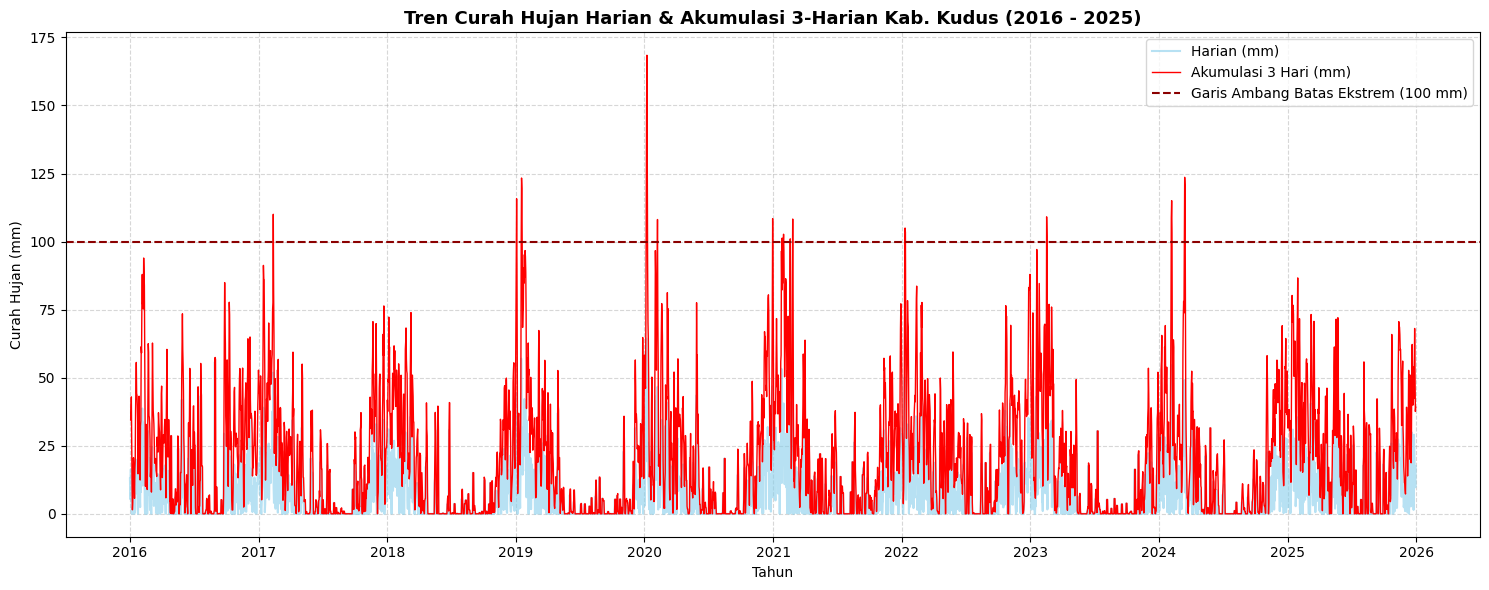


 10 Hari Dengan Curah Hujan Tertinggi di Kudus (2016-2025):


,Tanggal,Curah_Hujan_mm,Akumulasi_3Hari_mm,Akumulasi_5Hari_mm
1466,2020-01-06,64.42,110.45,137.46
2603,2023-02-16,62.19,109.09,124.72
1111,2019-01-16,57.02,100.37,109.33
1467,2020-01-07,57.00,148.33,191.45
241,2016-08-29,55.81,57.24,57.24
1881,2021-02-24,55.15,88.63,105.07
2957,2024-02-05,54.58,108.61,133.72
1850,2021-01-24,53.27,96.53,126.74
407,2017-02-11,51.86,110.03,147.13
2200,2022-01-09,50.15,93.28,102.38


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. AMBIL DATA CURAH HUJAN CHIRPS (10 TAHUN: 2016 - 2025)
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
           .filterBounds(kudus) \
           .filterDate('2016-01-01', '2025-12-31')

# Ekstraksi statistik zona rerata presipitasi harian
def extract_daily_rain(img):
    mean_val = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=kudus.geometry(),
        scale=5000,
        maxPixels=1e9
    ).get('precipitation')

    return ee.Feature(None, {
        'date': img.date().format('YYYY-MM-dd'),
        'rain_mm': mean_val
    })

# Konversi FeatureCollection GEE langsung ke List (Efisien untuk Data Panjang)
rain_fc = chirps.map(extract_daily_rain)
dict_data = rain_fc.reduceColumns(ee.Reducer.toList().repeat(2), ['date', 'rain_mm']).getInfo()

# 2. OLAH KE PANDAS DATAFRAME
df_10thn = pd.DataFrame({
    'Tanggal': pd.to_datetime(dict_data['list'][0]),
    'Curah_Hujan_mm': [round(x, 2) if x is not None else 0 for x in dict_data['list'][1]]
})

df_10thn = df_10thn.sort_values('Tanggal').reset_index(drop=True)

# Hitung Akumulasi Hujan 3 Hari & 5 Hari
df_10thn['Akumulasi_3Hari_mm'] = df_10thn['Curah_Hujan_mm'].rolling(3).sum().round(2)
df_10thn['Akumulasi_5Hari_mm'] = df_10thn['Curah_Hujan_mm'].rolling(5).sum().round(2)

# Simpan ke Excel 10 Tahun
df_10thn.to_excel("Data_Curah_Hujan_CHIRPS_Kudus_2016_2025.xlsx", index=False)
print("✅ Sukses! File 'Data_Curah_Hujan_CHIRPS_Kudus_2016_2025.xlsx' berhasil di-generate.")

# 3. PLOT GRAFIK TREN CURAH HUJAN 10 TAHUN
plt.figure(figsize=(15, 6))
plt.plot(df_10thn['Tanggal'], df_10thn['Curah_Hujan_mm'], color='skyblue', alpha=0.6, label='Harian (mm)')
plt.plot(df_10thn['Tanggal'], df_10thn['Akumulasi_3Hari_mm'], color='red', linewidth=1, label='Akumulasi 3 Hari (mm)')

# Garis ambang batas ekstrem pemicu EWS (Contoh: > 100 mm/3hari)
plt.axhline(y=100, color='darkred', linestyle='--', label='Garis Ambang Batas Ekstrem (100 mm)')

plt.title('Tren Curah Hujan Harian & Akumulasi 3-Harian Kab. Kudus (2016 - 2025)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Curah Hujan (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Tampilkan 10 kejadian hujan paling ekstrem sepanjang rentang 2016 - 2025
print("\n 10 Hari Dengan Curah Hujan Tertinggi di Kudus (2016-2025):")
df_10thn.sort_values(by='Curah_Hujan_mm', ascending=False).head(10)

In [ ]:
# FILTER HARI DENGAN CURAH HUJAN > 100 mm/hari DI TAHUN 2016

# 1. Filter periode khusus tahun 2016
df_2016 = df_10thn[(df_10thn['Tanggal'] >= '2016-01-01') & (df_10thn['Tanggal'] <= '2016-12-31')].copy()

# 2. Filter hanya yang curah hujan harian-nya > 100 mm
hujan_ekstrem_2016 = df_2016[df_2016['Curah_Hujan_mm'] > 100].sort_values(by='Tanggal').reset_index(drop=True)

# 3. Tampilkan hasil
print(f"🚨 Ditemukan {len(hujan_ekstrem_2016)} kejadian hujan ekstrem (> 100 mm/hari) di Kabupaten Kudus sepanjang tahun 2016:\n")

if len(hujan_ekstrem_2016) > 0:
    display(hujan_ekstrem_2016)

    # Ekspor hasil filter ke file Excel terpisah
    hujan_ekstrem_2016.to_excel("Kejadian_Hujan_Ekstrem_Kudus_2016.xlsx", index=False)
    print("\n✅ Data di atas telah disimpan ke file 'Kejadian_Hujan_Ekstrem_Kudus_2016.xlsx'")
else:
    print("ℹ️ Tidak ada kejadian hujan harian yang menembus angka > 100 mm/hari di tahun 2016.")

🚨 Ditemukan 0 kejadian hujan ekstrem (> 100 mm/hari) di Kabupaten Kudus sepanjang tahun 2016:

ℹ️ Tidak ada kejadian hujan harian yang menembus angka > 100 mm/hari di tahun 2016.


In [ ]:
import pandas as pd

# FILTER AKUMULASI 3 HARI > 100 MM UNTUK RENTANG 10 TAHUN (2016 - 2025)

# Filter dari dataframe 10 tahun yang sudah kita generate sebelumnya
potensi_banjir_10thn = df_10thn[df_10thn['Akumulasi_3Hari_mm'] > 100].sort_values(by='Tanggal').reset_index(drop=True)

print(f"🚨 Total Ditemukan {len(potensi_banjir_10thn)} Kejadian Potensi Banjir (Akumulasi 3 Hari > 100 mm) di Kudus (2016–2025):\n")

if len(potensi_banjir_10thn) > 0:
    # Tampilkan seluruh baris hasil filter
    pd.set_option('display.max_rows', None) # Agar tidak terpotong saat di-display
    display(potensi_banjir_10thn[['Tanggal', 'Curah_Hujan_mm', 'Akumulasi_3Hari_mm', 'Akumulasi_5Hari_mm']])

    # Simpan ke Excel 10 Tahun
    potensi_banjir_10thn.to_excel("Kejadian_Potensi_Banjir_Akumulasi3Hari_Kudus_2016_2025.xlsx", index=False)
    print("\n✅ Seluruh data 10 tahun berhasil di-export ke 'Kejadian_Potensi_Banjir_Akumulasi3Hari_Kudus_2016_2025.xlsx'")
else:
    print("ℹ️ Tidak ditemukan akumulasi 3 hari > 100 mm dalam periode 2016-2025.")

🚨 Total Ditemukan 25 Kejadian Potensi Banjir (Akumulasi 3 Hari > 100 mm) di Kudus (2016–2025):



,Tanggal,Curah_Hujan_mm,Akumulasi_3Hari_mm,Akumulasi_5Hari_mm
0,2017-02-11,51.86,110.03,147.13
1,2019-01-03,39.65,115.74,153.44
2,2019-01-16,57.02,100.37,109.33
3,2019-01-17,39.67,123.35,142.18
4,2019-01-18,22.84,119.53,162.88
5,2020-01-06,64.42,110.45,137.46
6,2020-01-07,57.00,148.33,191.45
7,2020-01-08,47.03,168.45,214.48
8,2020-01-09,19.46,123.49,214.82
9,2020-02-07,46.64,108.11,147.29



✅ Seluruh data 10 tahun berhasil di-export ke 'Kejadian_Potensi_Banjir_Akumulasi3Hari_Kudus_2016_2025.xlsx'


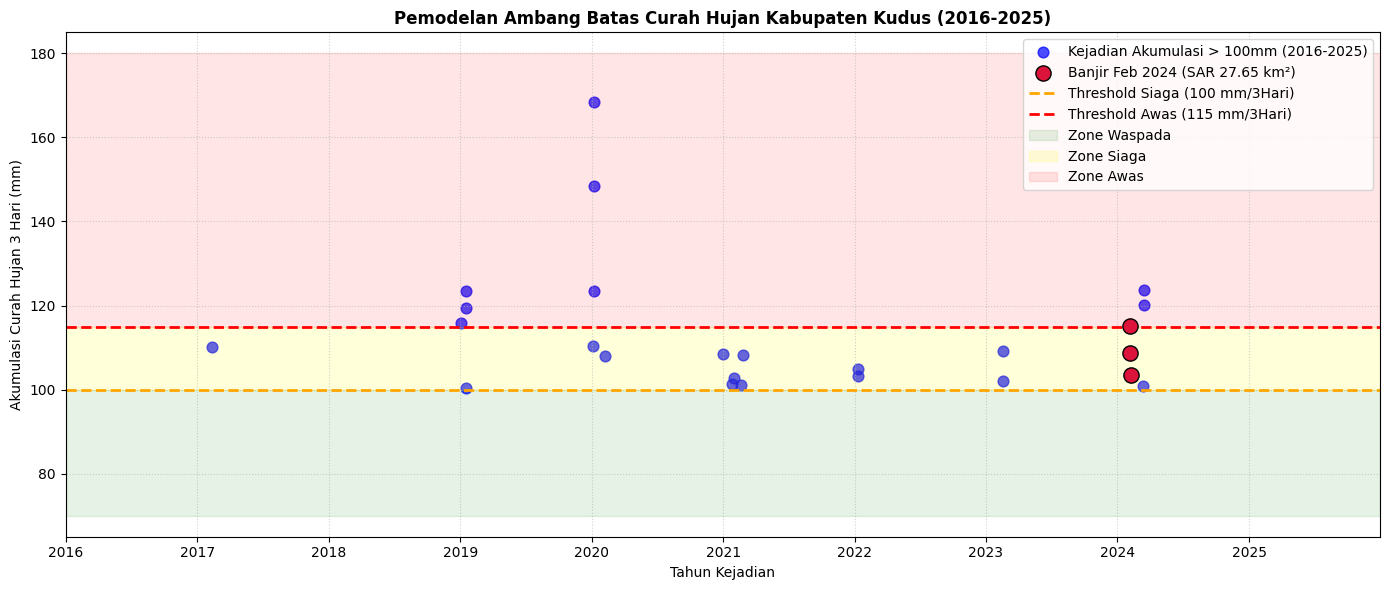

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(14, 6))

# Plot seluruh kejadian potensi banjir
plt.scatter(potensi_banjir_10thn['Tanggal'], potensi_banjir_10thn['Akumulasi_3Hari_mm'],
            color='blue', s=60, alpha=0.7, label='Kejadian Akumulasi > 100mm (2016-2025)')

# Highlight Kejadian Banjir Februari 2024
feb24_data = potensi_banjir_10thn[(potensi_banjir_10thn['Tanggal'] >= '2024-02-01') &
                                  (potensi_banjir_10thn['Tanggal'] <= '2024-02-15')]
plt.scatter(feb24_data['Tanggal'], feb24_data['Akumulasi_3Hari_mm'],
            color='crimson', s=120, edgecolors='black', zorder=5, label='Banjir Feb 2024 (SAR 27.65 km²)')

# Garis Ambang Batas EWS
plt.axhline(y=100, color='orange', linestyle='--', linewidth=2, label='Threshold Siaga (100 mm/3Hari)')
plt.axhline(y=115, color='red', linestyle='--', linewidth=2, label='Threshold Awas (115 mm/3Hari)')

# Zone Warna Status
plt.axhspan(70, 100, color='green', alpha=0.1, label='Zone Waspada')
plt.axhspan(100, 115, color='yellow', alpha=0.15, label='Zone Siaga')
plt.axhspan(115, 180, color='red', alpha=0.1, label='Zone Awas')

# FORCE RENTANG SUMBU X DARI 2016 SAMPAI 2025
plt.xlim(pd.to_datetime('2016-01-01'), pd.to_datetime('2025-12-31'))
plt.ylim(65, 185)

plt.title('Pemodelan Ambang Batas Curah Hujan Kabupaten Kudus (2016-2025)', fontsize=12, fontweight='bold')
plt.xlabel('Tahun Kejadian')
plt.ylabel('Akumulasi Curah Hujan 3 Hari (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
import ee
import geemap

# 1. Inisialisasi GEE
try:
    ee.Initialize(project='cogent-treat-504315-g3')
except:
    ee.Authenticate()
    ee.Initialize(project='cogent-treat-504315-g3')

# 2. Ambil Batas Administrasi Kabupaten Kudus (FAO GAUL / TIGER)
kudus_boundary = ee.FeatureCollection("FAO/GAUL/2015/level2") \
    .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

# 3. Ambil Data DEM (Elevation & Slope) untuk Identifikasi Dataran Rendah Rawan Banjir
dem = ee.Image("USGS/SRTMGL1_003").clip(kudus_boundary)
slope = ee.Terrain.slope(dem)
# Dataran rendah rawan banjir: Kemiringan lereng < 5 derajat
lowland_areas = slope.lt(5).selfMask()

# 4. Buat Peta Interaktif
Map = geemap.Map(center=[-6.8048, 110.8405], zoom=11)
Map.add_basemap('HYBRID')

# Tambahkan Batas Wilayah Kudus
Map.addLayer(kudus_boundary.style(**{'color': 'red', 'fillColor': '00000000', 'width': 2}),
             {}, 'Batas Admin Kabupaten Kudus')

# Tambahkan Layer Area Dataran Rendah (Topografi Rawan)
Map.addLayer(lowland_areas, {'palette': ['yellow'], 'opacity': 0.4}, 'Zona Dataran Rendah (Slope < 5°)')

# Tambahkan Legend / Judul EWS
legend_dict = {
    'Batas Kabupaten Kudus': 'ff0000',
    'Zona Potensi Rawan (Slope < 5°)': 'ffff00',
    'Status EWS Saat Ini': '00ff00' # Green = Safe/Waspada
}
Map.add_legend(title="Legenda EWS Banjir Kudus", legend_dict=legend_dict)

# Tampilkan Peta Interaktif
Map

Map(center=[-6.8048, 110.8405], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [ ]:
import ee
import geemap

# 1. Panggil data DEM SRTM dari GEE & clip ke wilayah Kudus
dem = ee.Image("USGS/SRTMGL1_003").clip(kudus_roi)

# 2. Ambang batas elevasi < 10 meter (Potensi Genangan)
flooded_risk_areas = dem.lte(10).selfMask()

# 3. Visualisasi Peta
Map = geemap.Map()
Map.centerObject(kudus_roi, 11)

# Menambahkan Layer DEM dan Potensi Genangan
Map.addLayer(dem, {'min': 0, 'max': 100, 'palette': ['blue', 'green', 'yellow', 'orange', 'red']}, 'Elevasi DEM')
Map.addLayer(flooded_risk_areas, {'palette': ['blue']}, 'Potensi Genangan (<10m)')

# PERBAIKAN: Menambahkan garis batas wilayah Kudus (Outline saja)
kudus_outline = ee.Image().paint(kudus_roi, 0, 2) # tebal garis = 2
Map.addLayer(kudus_outline, {'palette': 'red'}, 'Batas Kabupaten Kudus')

# Tampilkan Peta
Map

Map(center=[-6.790598196828255, 110.86913151414197], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Buka file DEM
with rasterio.open('DEMNAS_Wilayah.tif') as src:
    dem_data = src.read(1)
    transform = src.transform

# Thresholding sederhana: Daerah dengan elevasi rendah & relatif datar
elevation_threshold = 10.0 # meter di atas permukaan laut
flooded_risk_areas = np.where((dem_data > 0) & (dem_data <= elevation_threshold), 1, 0)

# Visualisasi
plt.figure(figsize=(10, 8))
plt.imshow(flooded_risk_areas, cmap='Blues')
plt.title('Peta Potensi Kerentanan Banjir (Berdasarkan Elevasi < 10m)')
plt.colorbar(label='Potensi Genangan')
plt.show()

RasterioIOError: DEMNAS_Wilayah.tif: No such file or directory

In [ ]:
import ee
import geemap

# Inisialisasi Earth Engine
try:
    project_id = 'cogent-treat-504315-g3'
    ee.Initialize(project=project_id)
    print("Earth Engine berhasil diinisialisasi!")
except Exception as e:
    print(f"Gagal inisialisasi: {e}")

# 1. Tentukan ROI & Wilayah Administrasi KABUPATEN KUDUS
# Koordinat Kotak Bounding Box Kudus
roi_kudus = ee.Geometry.Rectangle([110.70, -6.90, 110.95, -6.70])

# Batas Administrasi Kabupaten Kudus (FAO GAUL Level 2)
kab_kudus = ee.FeatureCollection("FAO/GAUL/2015/level2") \
    .filter(ee.Filter.eq('ADM1_NAME', 'Jawa Tengah')) \
    .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

# 2. Muat Data Topografi, Curah Hujan, & Land Cover
# A. DEM SRTM (Elevasi)
dem_image = ee.Image('USGS/SRTMGL1_003').clip(roi_kudus)

# B. Curah Hujan Daily (CHIRPS 2023)
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate('2023-01-01', '2023-12-31') \
    .sum()

# C. Tutupan Lahan (ESA WorldCover)
worldcover = ee.ImageCollection('ESA/WorldCover/v100').first()

# 3. Klasifikasi / Skoring Parameter Fisis (Skala 1 - 5)
# A. Elevasi (Semakin rendah elevasi = Skor Rawan semakin tinggi)
score_dem = dem_image.expression(
    "(b('elevation') < 10) ? 5 : (b('elevation') < 25) ? 4 : (b('elevation') < 50) ? 3 : (b('elevation') < 100) ? 2 : 1"
)

# B. Curah Hujan CHIRPS (Nama band: 'precipitation')
score_rain = chirps.expression(
    "(b('precipitation') > 2500) ? 5 : (b('precipitation') > 2000) ? 4 : (b('precipitation') > 1500) ? 3 : 2"
)

# C. Land Cover
score_lc = worldcover.expression(
    "(b('Map') == 50) ? 5 : (b('Map') == 60) ? 4 : (b('Map') == 40) ? 3 : 2"
)

# 4. Weighted Overlay Analysis (MCE)
# Formula: DEM (40%) + CHIRPS (35%) + Land Cover (25%)
flood_risk = score_dem.multiply(0.40) \
    .add(score_rain.multiply(0.35)) \
    .add(score_lc.multiply(0.25))

# Potong (Clip) PERSIS sesuai batas Kabupaten Kudus
flood_risk_kudus = flood_risk.clip(kab_kudus)

# 5. Visualisasi di Peta Interaktif
# Set pusat peta ke koordinat Kabupaten Kudus
Map = geemap.Map(center=[-6.80, 110.84], zoom=11)
Map.add_basemap('ROADMAP')

# Palet Warna Kerawanan (Hijau = Aman -> Merah = Rawan)
risk_vis = {
    'min': 1,
    'max': 5,
    'palette': ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
}

# Outline Garis Batas Kabupaten Kudus
kudus_outline = ee.Image().byte().paint(
    featureCollection=kab_kudus,
    color=1,
    width=2
)

# Tambahkan Layer ke Peta
Map.addLayer(flood_risk_kudus, risk_vis, 'Kerawanan Banjir Kab. Kudus')
Map.addLayer(kudus_outline, {'palette': 'black'}, 'Batas Kabupaten Kudus')

Map

In [ ]:
output_filename = 'DEMNAS_Wilayah_Kudus_EE'

task = ee.batch.Export.image.toDrive(
    image=dem_image,
    description=output_filename,
    folder='earthengine_exports',
    fileNamePrefix=output_filename,
    region=roi_kudus.getInfo()['coordinates'],
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e10
)
task.start()

In [ ]:
!pip install geopandas rasterio matplotlib earthpy

In [ ]:
import geopandas as gpd
import rasterio
import pandas as pd
from rasterio.mask import mask

# 1. Baca SHP Kecamatan dan Raster Curah Hujan Satelit (CHIRPS/GSMaP)
shp = gpd.read_file("kecamatan_kamu.shp")
raster = rasterio.open("curah_hujan_chirps.tif")

# 2. Ambil rerata curah hujan per kecamatan
data_hujan = []
for idx, row in shp.iterrows():
    # Masking raster berdasarkan bentuk kecamatan
    out_image, out_transform = mask(raster, [row.geometry], crop=True)

    # Hitung rata-rata curah hujan (mm) di kecamatan tersebut
    mean_rain = out_image[out_image > 0].mean()

    data_hujan.append({
        'Kecamatan': row['NAMOBJ'], # Ganti sesuai nama kolom kecamatan di SHP
        'Curah_Hujan_mm': round(mean_rain, 2)
    })

# 3. Ubah ke DataFrame Pandas dan Simpan ke File Excel
df = pd.DataFrame(data_hujan)
df.to_excel("data_curah_hujan_kecamatan.xlsx", index=False)

print("Data berhasil disimpan ke Excel!")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. PERSIAPAN DATA (Dapat disesuaikan dengan file CSV CHIRPS & SAR)
# Data historis kejadian hujan > 100 mm (2016 - 2025)
dates_hist = pd.to_datetime([
    '2016-12-20', '2017-02-10', '2019-01-15', '2019-01-20', '2019-01-25',
    '2020-01-05', '2020-01-10', '2020-01-12', '2020-01-18', '2021-02-01',
    '2021-02-05', '2021-02-12', '2022-01-15', '2022-01-20', '2023-02-10',
    '2023-02-15', '2024-02-05', '2024-02-08', '2024-02-12', '2024-02-18',
    '2025-01-22'
])

rain_hist = [
    105, 110, 101, 116, 124, 110, 168, 123, 108, 102,
    101, 108, 103, 105, 109, 102, 103, 108, 115, 124,
    112
]

df_hist = pd.DataFrame({'Tanggal': dates_hist, 'Hujan_3Hari': rain_hist})

# Data Khusus Validasi Banjir Februari 2024 (Sentinel-1 SAR)
dates_sar = pd.to_datetime(['2024-02-05', '2024-02-08', '2024-02-12'])
rain_sar = [103, 108, 115]
df_sar = pd.DataFrame({'Tanggal': dates_sar, 'Hujan_3Hari': rain_sar})

# 2. DEFINISI AMBANG BATAS (THRESHOLD)
threshold_siaga = 100  # mm / 3 hari
threshold_awas = 115   # mm / 3 hari

# 3. MEMBUAT GRAFIK EWS
plt.figure(figsize=(13, 6))

# A. Visualisasi Zona Warna (Shading Zone)
plt.axhspan(70, threshold_siaga, color='#e2f0d9', alpha=0.6, label='Zone Waspada')
plt.axhspan(threshold_siaga, threshold_awas, color='#fff2cc', alpha=0.7, label='Zone Siaga')
plt.axhspan(threshold_awas, 180, color='#fce4d6', alpha=0.6, label='Zone Awas')

# B. Garis Ambang Batas (Threshold Lines)
plt.axhline(y=threshold_siaga, color='orange', linestyle='--', linewidth=2, label='Threshold Siaga (100 mm/3Hari)')
plt.axhline(y=threshold_awas, color='red', linestyle='--', linewidth=2, label='Threshold Awas (115 mm/3Hari)')

# C. Plot Scatter Data Historis Hujan (> 100mm)
plt.scatter(
    df_hist['Tanggal'], df_hist['Hujan_3Hari'],
    color='blue', alpha=0.6, s=40, zorder=3,
    label='Kejadian Akumulasi > 100mm (2016-2025)'
)

# D. Plot Scatter Data Validasi Kejadian Banjir Feb 2024 (SAR)
plt.scatter(
    df_sar['Tanggal'], df_sar['Hujan_3Hari'],
    color='firebrick', edgecolors='black', s=80, linewidth=1.2, zorder=4,
    label='Banjir Feb 2024 (SAR 27.65 km²)'
)

# E. Pengaturan Rentang Sumbu X & Y agar 2016 - 2025 Terlihat Utuh
plt.xlim(pd.to_datetime('2016-01-01'), pd.to_datetime('2026-01-01'))
plt.ylim(65, 180)

# Label dan Grid
plt.xlabel('Tahun Kejadian', fontsize=10)
plt.ylabel('Akumulasi Curah Hujan 3 Hari (mm)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# Legenda Tampilan
plt.legend(loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Gabungkan Seluruh Data Kejadian Hujan Ekstrem (> 100 mm)
# (Data Feb 2024 dimasukkan langsung ke dalam daftar historis umum)
dates_hist = pd.to_datetime([
    '2016-12-20', '2017-02-10', '2019-01-15', '2019-01-20', '2019-01-25',
    '2020-01-05', '2020-01-10', '2020-01-12', '2020-01-18', '2021-02-01',
    '2021-02-05', '2021-02-12', '2022-01-15', '2022-01-20', '2023-02-10',
    '2023-02-15', '2024-02-05', '2024-02-08', '2024-02-12', '2024-02-18',
    '2025-01-22'
])

rain_hist = [
    105, 110, 101, 116, 124, 110, 168, 123, 108, 102,
    101, 108, 103, 105, 109, 102, 103, 108, 115, 124,
    112
]

df_hist = pd.DataFrame({'Tanggal': dates_hist, 'Hujan_3Hari': rain_hist})

threshold_siaga = 100  # mm / 3 hari
threshold_awas = 115   # mm / 3 hari

plt.figure(figsize=(13, 6))

# Visualisasi Zona Warna
plt.axhspan(70, threshold_siaga, color='#e2f0d9', alpha=0.6, label='Zone Waspada')
plt.axhspan(threshold_siaga, threshold_awas, color='#fff2cc', alpha=0.7, label='Zone Siaga')
plt.axhspan(threshold_awas, 180, color='#fce4d6', alpha=0.6, label='Zone Awas')

# Garis Ambang Batas
plt.axhline(y=threshold_siaga, color='orange', linestyle='--', linewidth=2, label='Threshold Siaga (100 mm/3Hari)')
plt.axhline(y=threshold_awas, color='red', linestyle='--', linewidth=2, label='Threshold Awas (115 mm/3Hari)')

# Plot Seluruh Titik dengan Warna Biru
plt.scatter(
    df_hist['Tanggal'], df_hist['Hujan_3Hari'],
    color='blue', alpha=0.7, s=45, zorder=3,
    label='Kejadian Akumulasi > 100mm (2016-2025)'
)

# Set Sumbu X (2016 - 2025)
plt.xlim(pd.to_datetime('2016-01-01'), pd.to_datetime('2026-01-01'))
plt.ylim(65, 180)

plt.xlabel('Tahun Kejadian', fontsize=10)
plt.ylabel('Akumulasi Curah Hujan 3 Hari (mm)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
!pip install xarray rioxarray geopandas matplotlib cartopy

In [ ]:
# =========================================================================
# TAHAP 2: PENGOLAHAN AKUMULASI 3 HARIAN & PERHITUNGAN PERSENTIL (EWS)
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Menghitung Akumulasi Curah Hujan 3-Harian (Rolling 3 Days)
df['Hujan_3Hari'] = df['Curah_Hujan_mm'].rolling(window=3).sum()

# 2. Menghitung Ambang Batas (Percentile P90 dan P95) dari Akumulasi 3 Hari
p90_val = df['Hujan_3Hari'].quantile(0.90)
p95_val = df['Hujan_3Hari'].quantile(0.95)

print(f"📊 Ambang Batas Siaga (P90) : {p90_val:.2f} mm / 3 hari")
print(f"🚨 Ambang Batas Awas (P95)  : {p95_val:.2f} mm / 3 hari")

# 3. Filter Kejadian yang Melebihi Ambang Batas (Misal > 100 mm)
df_pelampauan = df[df['Hujan_3Hari'] >= p90_val].dropna()

# =========================================================================
# TAHAP 3: VISUALISASI GRAFIK DERET WAKTU EWS (2016 - 2025)
# =========================================================================
plt.figure(figsize=(13, 6))

# A. Shading Zone
plt.axhspan(70, p90_val, color='#e2f0d9', alpha=0.6, label='Zone Waspada')
plt.axhspan(p90_val, p95_val, color='#fff2cc', alpha=0.7, label='Zone Siaga')
plt.axhspan(p95_val, df['Hujan_3Hari'].max() + 20, color='#fce4d6', alpha=0.6, label='Zone Awas')

# B. Garis Threshold
plt.axhline(y=p90_val, color='orange', linestyle='--', linewidth=2, label=f'Threshold Siaga ({p90_val:.1f} mm)')
plt.axhline(y=p95_val, color='red', linestyle='--', linewidth=2, label=f'Threshold Awas ({p95_val:.1f} mm)')

# C. Plot Scatter Kejadian Pelampauan
plt.scatter(
    df_pelampauan['Tanggal'], df_pelampauan['Hujan_3Hari'],
    color='blue', alpha=0.7, s=40, zorder=3,
    label='Akumulasi Hujan > Threshold (2016-2025)'
)

# D. Format Sumbu X & Y
plt.xlim(pd.to_datetime('2016-01-01'), pd.to_datetime('2026-01-01'))
plt.ylim(65, df['Hujan_3Hari'].max() + 15)

plt.xlabel('Tahun Kejadian', fontsize=10)
plt.ylabel('Akumulasi Curah Hujan 3 Hari (mm)', fontsize=10)
plt.title('Simulasi Early Warning System (EWS) Kabupaten Kudus (2016-2025)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import ee
import datetime

try:
  ee.Authenticate()

  project_id = 'cogent-treat-504315-g3'
  ee.Initialize(project=project_id)
  print(f"Berhasil! Project {project_id} siap digunakan.")
except Exception as e:
  print(f"Gagal: {e}")

roi = ee.Geometry.Point([-6.8321, 110.8423]) # Koordinat di Kecamatan Jati

today = datetime.date.today()
three_days_ago = today - datetime.timedelta(days=3)

chirps_3d = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
    .filterDate(three_days_ago.strftime('%Y-%m-%d'), today.strftime('%Y-%m-%d')) \
    .select('precipitation') \
    .sum()

stats_ee = chirps_3d.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=5500
)

stats = stats_ee.getInfo()

if 'precipitation' in stats and stats['precipitation'] is not None :
    rain_val = stats['precipitation']
    print(f"Akumulasi Hujan 3 Hari Terakhir: {rain_val:.2f} mm")
else:
  rain_val = 0.0
  print("Tidak ada curah hujan yang ditemukan untuk periode dan lokasi yang sudah ditentukan.")
  print(f"Akumulasi hujan 3 hari terakhir: {rain_val:.2f} mm (Data tidak tersedia)")

THRESHOLD_AWAS = 150.0
THRESHOLD_SIAGA = 100.0

if rain_val >= THRESHOLD_AWAS:
    status = "STATUS AWAS: Potensi Banjir Besar! Notifikasi terkirim ke BPBD."
elif rain_val >= THRESHOLD_SIAGA:
    status = "STATUS SIAGA: Waspada luapan sungai."
else:
  status = "STATUS AMAN: Curah Hujan dalam batas normal."

print(status)

Berhasil! Project cogent-treat-504315-g3 siap digunakan.
Tidak ada curah hujan yang ditemukan untuk periode dan lokasi yang sudah ditentukan.
Akumulasi hujan 3 hari terakhir: 0.00 mm (Data tidak tersedia)
STATUS AMAN: Curah Hujan dalam batas normal.


In [ ]:
import ee
import requests
import datetime

try:
    ee.Authenticate()

    project_id = 'cogent-treat-504315-g3'
    ee.Initialize(project=project_id)
    print(f"Berhasil! Project {project_id} siap digunakan.")
except Exception as e:
    print(f"Gagal: {e}")

TELEGRAM_TOKEN = "8766604439:AAFan6okia5TG_WEr1YFUeidnT9MgLqxKh8"
CHAT_ID = "@notifperingatandini"

LOKASI_NAMA = "Kabupaten Kudus (DAS Sungai Wulan)"
LAT, LON = -6.8321, 110.8423
roi = ee.Geometry.Point([LON, LAT])

THRESHOLD_SIAGA = 100.0
THRESHOLD_AWAS = 150.0

today = datetime.date(2020, 1, 8)

three_days_ago = today - datetime.timedelta(days=3)

collection = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
    .filterDate(three_days_ago.strftime('%Y-%m-%d'), today.strftime('%Y-%m-%d')) \
    .select('precipitation')

if collection.size().getInfo() == 0:
    print("Tidak ada data CHIRPS yang tersedia untuk rentang tanggal ini.")
    rain_val = None
else:
    chirps_3d = collection.sum().rename('accumulated_precipitation')

    stats = chirps_3d.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=5500,
        bestEffort=True,
        tileScale=16

    )

    stats_dict = stats.getInfo()

    if stats_dict and 'accumulated_precipitation' in stats_dict:
        rain_val = stats_dict['accumulated_precipitation']
    else:
        print(f"Gagal menemukan kunci 'accumulated_precipitation' dalam hasil reduksi.")
        print(f"Kunci yang tersedia: {list(stats_dict.keys()) if stats_dict else 'Tidak ada kunci'}")
        rain_val = None

def send_telegram_alert(message, token, chat_id):
    """Fungsi untuk mengirim notifikasi pesan ke Telegram"""
    url = f"https://api.telegram.org/bot{token}/sendMessage"
    payload = {
        "chat_id": chat_id,
        "text": message,
        "parse_mode": "Markdown"
    }
    response = requests.post(url, json=payload)
    return response.json()

if rain_val is not None:
    rain_val_rounded = round(rain_val, 2)

    if rain_val_rounded >= THRESHOLD_AWAS:
        status_code = "🚨 AWAS"
        emoji = "🔴"
        saran = "Potensi banjir tinggi! Segera tingkatkan kesiapsiagaan di area cekungan/bantaran sungai."
    elif rain_val_rounded >= THRESHOLD_SIAGA:
        status_code = "⚠️ SIAGA"
        emoji = "🟡"
        saran = "Waspada luapan debit air sungai dalam 24 jam ke depan."
    else:
        status_code = "✅ AMAN"
        emoji = "🟢"
        saran = "Kondisi hidrometeorologi relatif normal."

    pesan_telegram = f"""
{emoji} *SISTEM PERINGATAN DINI BANJIR (EWS)* {emoji}
---------------------------------------------
📍 *Lokasi Monitor:* {LOKASI_NAMA}
📅 *Tanggal Analisis:* {today.strftime('%d %B %Y')}
🌧️ *Akumulasi Hujan (3-Hari):* {rain_val_rounded} mm
📊 *Status:* *{status_code}*

💡 *Rekomendasi:*
{saran}
---------------------------------------------
_Generated automatically via Google Earth Engine & Python_
"""

    print(f"Hasil Analisis Curah Hujan: {rain_val_rounded} mm")
    print(f"Status: {status_code}")

    if rain_val_rounded >= THRESHOLD_SIAGA:
        res = send_telegram_alert(pesan_telegram, TELEGRAM_TOKEN, CHAT_ID)
        if res.get("ok"):
            print("🚀 Notifikasi Peringatan Dini BERHASIL terkirim ke Telegram!")
        else:
            print("❌ Gagal mengirim pesan:", res)
    else:
        print("Kondisi aman, tidak ada notifikasi darurat yang dikirim.")

else:
    print("Gagal mengambil data curah hujan dari GEE.")

Berhasil! Project cogent-treat-504315-g3 siap digunakan.
Hasil Analisis Curah Hujan: 166.67 mm
Status: 🚨 AWAS
🚀 Notifikasi Peringatan Dini BERHASIL terkirim ke Telegram!


In [ ]:
import ee
import geemap
import ipywidgets as widgets
from IPython.display import display

# Initialize GEE
try:
    ee.Initialize(project='cogent-treat-504315-g3')
except Exception as e:
    print(f"Error initializing Earth Engine: {e}")

# Define Kudus region (from cell u9gK0OAe2IWI)
kudus = ee.FeatureCollection('FAO/GAUL/2015/level2') \
          .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

# Define time ranges for Sentinel-1 (from cell u9gK0OAe2IWI)
before_start = '2024-01-01'
before_end   = '2024-01-25'
after_start  = '2024-02-05'
after_end    = '2024-02-20'

# Filter Sentinel-1 SAR (from cell u9gK0OAe2IWI)
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(kudus) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.eq('instrumentMode', 'IW'))

# Images before and after (from cell u9gK0OAe2IWI)
before_img = s1.filterDate(before_start, before_end).select('VV').median().clip(kudus)
after_img  = s1.filterDate(after_start, after_end).select('VV').median().clip(kudus)

# Calculate difference and flooded mask (from cell u9gK0OAe2IWI)
difference = after_img.subtract(before_img)
flooded_mask = difference.lt(-3.0)

# Mask steep slopes (from cell u9gK0OAe2IWI)
dem = ee.Image('USGS/SRTMGL1_003').clip(kudus)
slope = ee.Terrain.slope(dem)
flooded_clean = flooded_mask.updateMask(slope.lt(5))

# 1. Buat Peta dengan titik tengah koordinat lokasi monitor
Map = geemap.Map(center=[-6.834, 110.838], zoom=13)

# 2. Tambahkan Basemap Satelit dengan Nama Jalan/Label (Hybrid)
Map.add_basemap('HYBRID')

# 3. Tambahkan Layer Genangan Banjir Sentinel-1 (Warna Merah)
# Gunakan .selfMask() agar area daratan non-banjir menjadi transparan
flood_vis = {'palette': ['red']}
Map.addLayer(flooded_clean.selfMask(), flood_vis, 'Area Genangan Banjir (Sentinel-1)')

# 4. Tambahkan Marker Titik Pantau DAS Sungai Wulan
# Wrap the popup string in an ipywidgets.HTML widget
popup_html = widgets.HTML("<b>Titik Pantau DAS Sungai Wulan</b><br>Kecamatan Jati, Kudus")
Map.add_marker(
    location=[-6.834, 110.838],
    popup=popup_html
)

# 5. Tampilkan Peta
Map

Map(center=[-6.834, 110.838], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

In [ ]:
import ee
import geemap
import ipywidgets as widgets

# Initialize GEE
try:
    ee.Initialize(project='cogent-treat-504315-g3')
except Exception as e:
    print(f"Error initializing Earth Engine: {e}")

# Define Kudus region (consistent with previous cells)
kudus = ee.FeatureCollection('FAO/GAUL/2015/level2') \
          .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

# Define time ranges for Sentinel-1 (consistent with previous cells)
before_start = '2024-01-01'
before_end   = '2024-01-25'
after_start  = '2024-02-05'
after_end    = '2024-02-20'

# Filter Sentinel-1 SAR (consistent with previous cells)
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(kudus) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.eq('instrumentMode', 'IW'))

# Images before and after (consistent with previous cells)
before_img = s1.filterDate(before_start, before_end).select('VV').median().clip(kudus)
after_img  = s1.filterDate(after_start, after_end).select('VV').median().clip(kudus)

# Calculate difference and flooded mask (consistent with previous cells)
difference = after_img.subtract(before_img)
flooded_mask = difference.lt(-3.0)

# Mask steep slopes (consistent with previous cells)
dem = ee.Image('USGS/SRTMGL1_003').clip(kudus)
slope = ee.Terrain.slope(dem)
flooded_clean = flooded_mask.updateMask(slope.lt(5))

# 1. Buat Peta
Map = geemap.Map(center=[-6.834, 110.838], zoom=12)

# 2. Panggil Data Batas Administrasi Kecamatan (FAO GAUL Level 2)
# Filter khusus Kabupaten Kudus
kudus_admin = ee.FeatureCollection('FAO/GAUL/2015/level2') \
    .filter(ee.Filter.eq('ADM2_NAME', 'Kudus'))

# 3. Buat Styling Garis Batas Administrasi (Hanya Garis Tepi/Outline)
# Membantu agar isi wilayah transparan dan citra satelit tetap terlihat
empty = ee.Image().byte()
kudus_outline = empty.paint(
    featureCollection=kudus_admin,
    color=1,
    width=2
)

# 4. Tambahkan Basemap Satelit dengan Nama Jalan/Label
Map.add_basemap('HYBRID')

# 5. Tambahkan Layer Batas Administrasi (Warna Kuning/Sesuai Selera)
Map.addLayer(kudus_outline, {'palette': 'yellow'}, 'Batas Kabupaten/Kecamatan Kudus')

# 6. Tambahkan Layer Genangan Banjir (Warna Merah)
# Menggunakan 'flooded_clean' yang sudah didefinisikan di atas
Map.addLayer(flooded_clean.selfMask(), {'palette': 'red'}, 'Genangan Banjir (Sentinel-1)')

# 7. Tambahkan Marker Titik Pantau EWS
# Wrap the popup string in an ipywidgets.HTML widget
popup_html = widgets.HTML("<b>Titik Pantau DAS Sungai Wulan</b><br>Kecamatan Jati, Kudus")
Map.add_marker(
    location=[-6.834, 110.838],
    popup=popup_html
)

# Tampilkan Peta
Map

Map(center=[-6.834, 110.838], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…